
# U.S. Wind Energy Generation: A Time Series Analysis

## Abstract

This project analyzes monthly U.S. net wind energy generation (thousand MWh) 
from January 2001 to December 2025, sourced from the U.S. Energy Information 
Administration (EIA). Following the three-phase methodology of identification, 
estimation, and forecasting, a SARIMA(0,1,1)(0,1,1)[12] model was selected 
and validated through residual diagnostics. The model produces a 24-month 
ahead forecast with a MAPE of 10.53%, indicating acceptable accuracy.



## 1. Introduction


Wind energy has grown dramatically in the United States over the past 
two decades, becoming one of the fastest growing sources of electricity. 
I chose this topic because I am genuinely interested in renewable energy 
and natural resources, and I wanted to work with data that has real-world 
relevance.


Wind energy is at the center of current political and economic debates 
in the U.S. — government policies and energy prices directly shape its 
growth. Reliable forecasting of wind generation has therefore become 
essential for grid stability, investment planning, and meeting climate 
targets.


This project applies time series modeling to monthly U.S. wind generation 
data from 2001 to 2025, with the goal of capturing its systematic 
structure and producing reliable short-term forecasts.



## 2. Model Specification


### 2a. Data Loading and Initial Plot

We begin by loading and cleaning the raw EIA data, constructing a time series 
object, and plotting the series to identify visible patterns.


Warning message:
"package 'tseries' is in use and will not be installed"


Number of observations: 301 
Expected (Dec 2000 to Dec 2025 = 301): 301 
Any NAs: 0 
Analysis series length: 300 (expected 300)
Training observations: 288 
Test observations: 12 


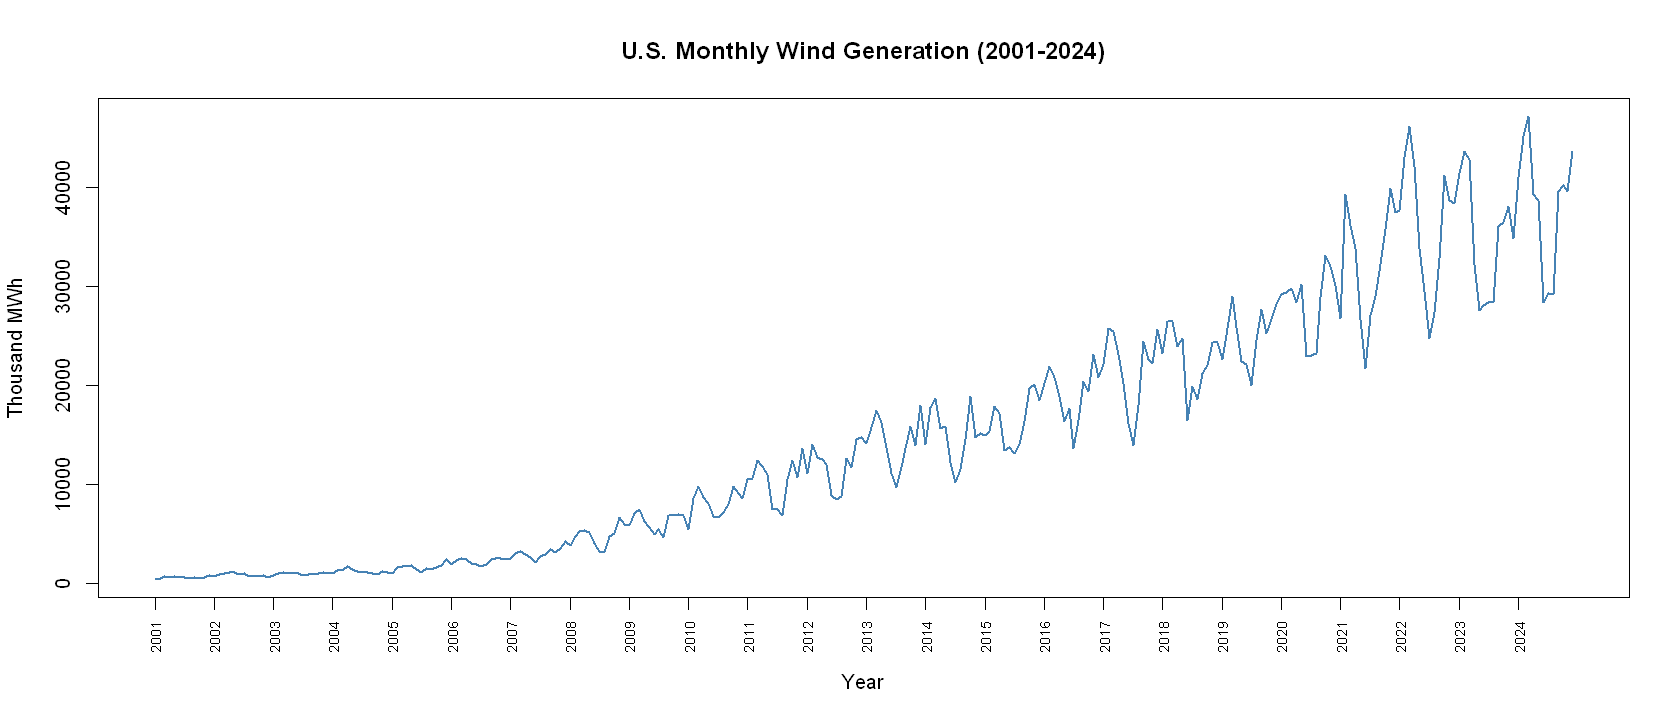

In [ ]:

install.packages("tseries", dependencies = TRUE)
library(tseries)

# Setting plots theme
set_theme <- function() {
  par(bg = "white", 
      col.main = "black", 
      col.lab  = "black", 
      col.axis = "black", 
      fg       = "black")
}

# Load raw data (skip 4 header lines)
raw_wind <- read.csv("Net_generation_wind_all_sectors_monthly.csv", skip = 4)

# Keep only numeric rows
clean_wind <- raw_wind[
  !is.na(raw_wind$United.States.thousand.megawatthours) &
  raw_wind$United.States.thousand.megawatthours != "", ]

# Reverse (EIA stores newest first) and convert to numeric
y_values <- as.numeric(rev(clean_wind$United.States.thousand.megawatthours))

# Verification check
cat("Number of observations:", length(y_values), "\n")
cat("Expected (Dec 2000 to Dec 2025 = 301):", 301, "\n")
cat("Any NAs:", sum(is.na(y_values)), "\n")

# Build full time series starting Dec 2000
wind_ts_full <- ts(y_values, start = c(2000, 12), frequency = 12)

# Extract Jan 2001 onwards for analysis
wind_ts <- window(wind_ts_full, start = c(2001, 1))
cat("Analysis series length:", length(wind_ts), 
    "(expected 300)\n")

# Train: Jan 2001 - Dec 2024 | Test: Jan 2025 - Dec 2025
wind_train <- window(wind_ts, end   = c(2024, 12))
wind_test  <- window(wind_ts, start = c(2025, 1))

cat("Training observations:", length(wind_train), "\n")
cat("Test observations:",     length(wind_test),  "\n")


set_theme()
plot(wind_train,
     main  = "U.S. Monthly Wind Generation (2001-2024)",
     ylab  = "Thousand MWh",
     xlab  = "Year",
     type  = "l",
     col   = "steelblue",
     lwd   = 2,
     xaxt  = "n")  # suppress default x axis

# Add custom x axis with year
axis(1, 
     at     = time(wind_train)[seq(1, length(wind_train), by = 12)],
     labels = format(time(wind_train)[seq(1, length(wind_train), by = 12)], 
                     format = "%Y"),
     las    = 2,
     cex.axis = 0.7)


The series displays a strong upward trend reflecting the rapid expansion of U.S. wind capacity.

The variance clearly increases over time (the fluctuations in later years are much larger than in early 
years). 

Hence, a log transformation is needed to stabilize it.


### 2b. Log Transformation

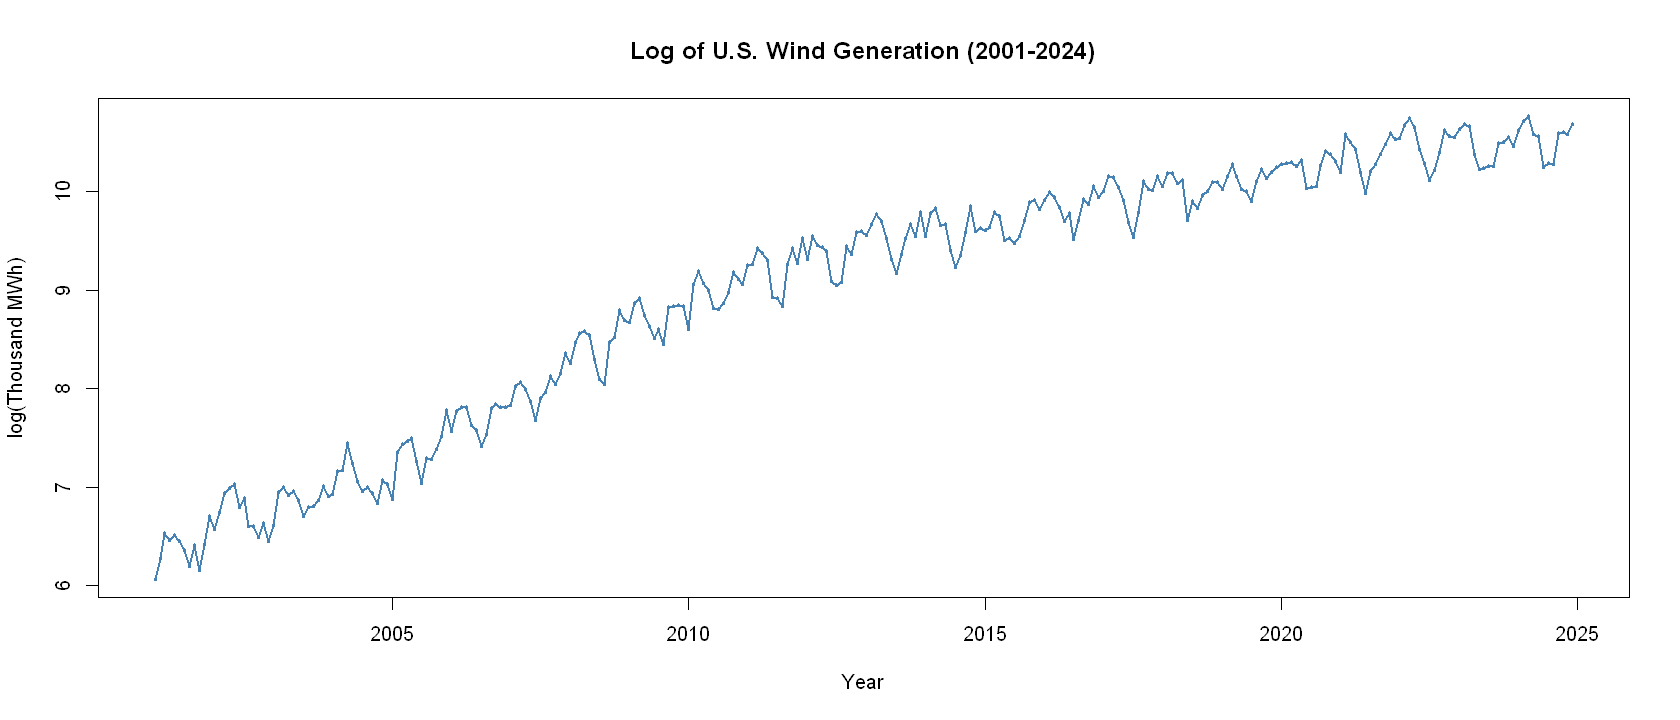

In [37]:
log_train <- log(wind_train)

set_theme()
plot(log_train,
     main = "Log of U.S. Wind Generation (2001-2024)",
     ylab = "log(Thousand MWh)",
     xlab = "Year",
     type = "o",
     col  = "steelblue",
     cex  = 0.3,
     lwd  = 2)


After the log transformation, the variance appears more stable across the 
period. The strong upward trend remains visible and must be addressed 
through differencing.


### 2c. Stationarity Testing

We apply the Augmented Dickey-Fuller (ADF) test and the KPSS test to 
formally confirm that the log series is non-stationary before differencing.


In [38]:
adf.test(log_train)
kpss.test(log_train, null = "Trend")


	Augmented Dickey-Fuller Test

data:  log_train
Dickey-Fuller = -1.9351, Lag order = 6, p-value = 0.6035
alternative hypothesis: stationary


Warning message in kpss.test(log_train, null = "Trend"):
"p-value smaller than printed p-value"



	KPSS Test for Trend Stationarity

data:  log_train
KPSS Trend = 1.1044, Truncation lag parameter = 5, p-value = 0.01


The ADF test fails to reject the null hypothesis of a unit root 
(p-value = 0.60), confirming the series is non-stationary. The KPSS 
test rejects the null of stationarity (p-value = 0.01), further 
confirming non-stationarity. Both tests agree — the log series 
requires differencing before modeling.


### 2d. First Differencing

We take first differences of the log series to remove the trend and 
re-examine stationarity.


Warning message in adf.test(diff_log):
"p-value smaller than printed p-value"



	Augmented Dickey-Fuller Test

data:  diff_log
Dickey-Fuller = -9.4896, Lag order = 6, p-value = 0.01
alternative hypothesis: stationary


Warning message in kpss.test(diff_log, null = "Level"):
"p-value greater than printed p-value"



	KPSS Test for Level Stationarity

data:  diff_log
KPSS Level = 0.12447, Truncation lag parameter = 5, p-value = 0.1


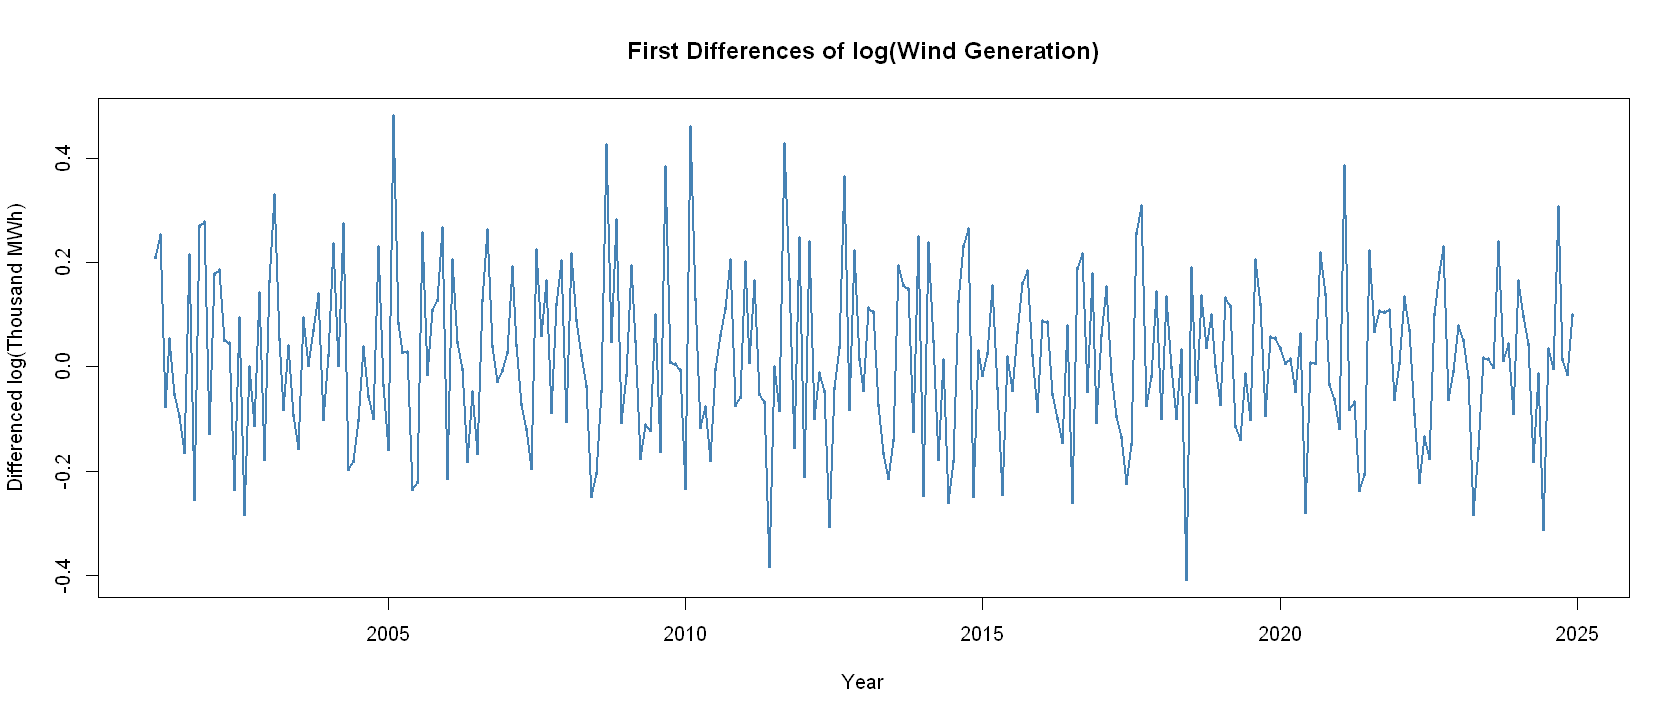

In [39]:
diff_log <- diff(log_train, lag = 1)

set_theme()
plot(diff_log,
     main = "First Differences of log(Wind Generation)",
     ylab = "Differenced log(Thousand MWh)",
     xlab = "Year",
     type = "o",
     col  = "steelblue",
     cex  = 0.3,
     lwd  = 2)

adf.test(diff_log)
kpss.test(diff_log, null = "Level")

After first differencing, the ADF test rejects the null of a unit root 
(p-value = 0.01), and the KPSS test fails to reject stationarity 
(p-value = 0.1). Both tests now agree the differenced series is 
stationary. We set d = 1.

the oscillating pattern suggests seasonal structure remains in the series, 
which will be examined through the ACF and PACF.


### 2e. ACF and PACF of the Differenced Series

We examine the sample ACF and PACF to identify the non-seasonal orders 
p and q, and to detect any remaining seasonal structure.


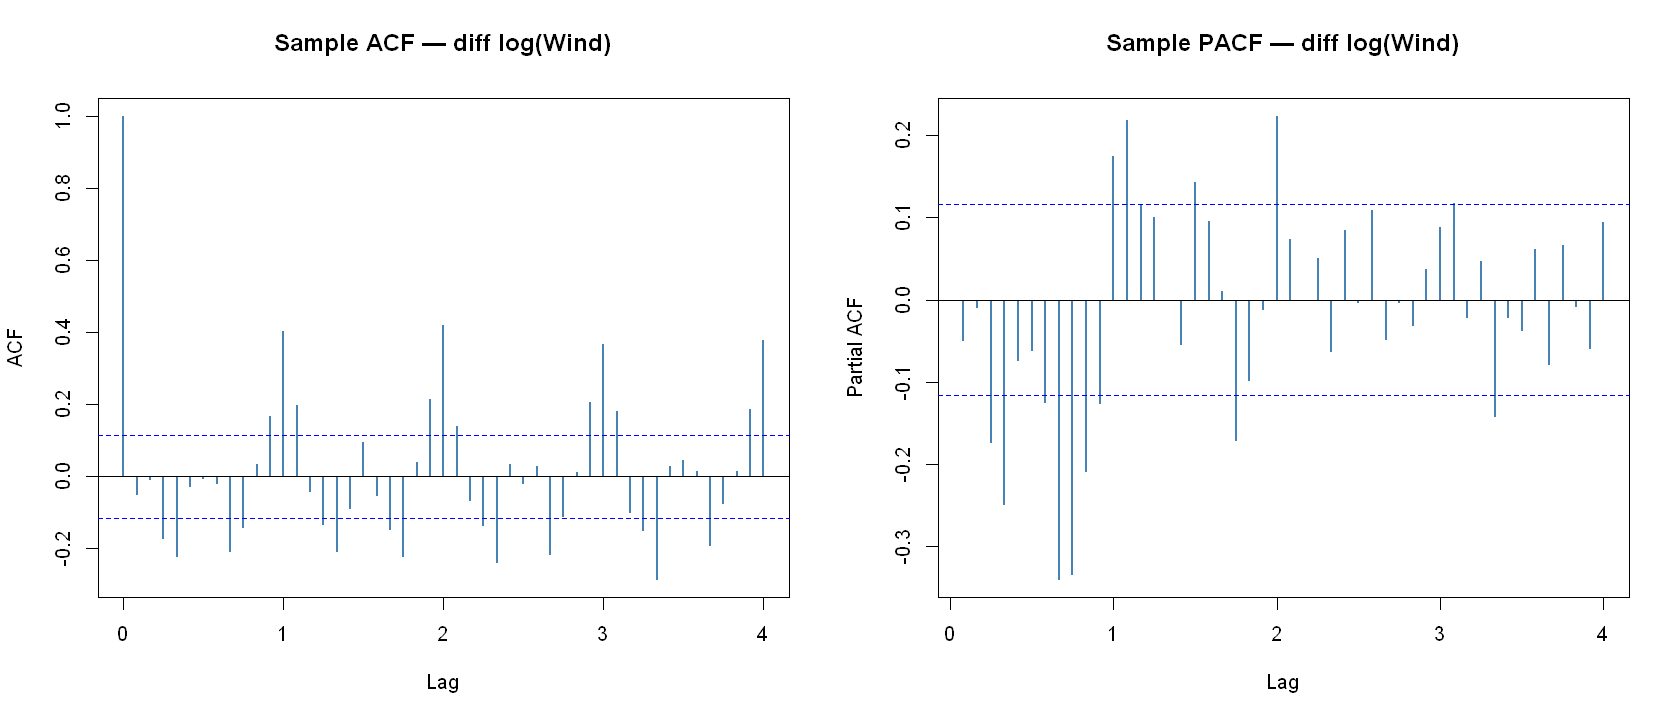

In [ ]:
options(repr.plot.width = 14, repr.plot.height = 6)
par(mfrow = c(1, 2))
set_theme()
acf(diff_log,
    main    = "Sample ACF — diff log(Wind)",
    lag.max = 48,
    col     = "steelblue",
    lwd = 2)
pacf(diff_log,
     main    = "Sample PACF — diff log(Wind)",
     lag.max = 48,
     col     = "steelblue",
     lwd = 2)
par(mfrow = c(1, 1))

Just a note: 
the x-axis displays lags in years (1 = 12 months, 2 = 24 months, 
3 = 36 months, 4 = 48 months) due to the monthly frequency of the series.

The ACF shows significant spikes at lags 12 and 24 .. (shown as lags 1 
and 2 .. on the plot), with repeating pattern at every seasonal lag interval, confirming strong seasonal autocorrelation at the annual frequency. 

The PACF shows significant spikes at early lags and at the seasonal lags. This 
confirms that a standard ARIMA model is insufficient and a SARIMA 
framework with seasonal differencing is required.



### 2f. Seasonal Differencing

To address the seasonal non-stationarity identified in the ACF/PACF, 
we apply a seasonal difference at lag 12 (12 months in the year)

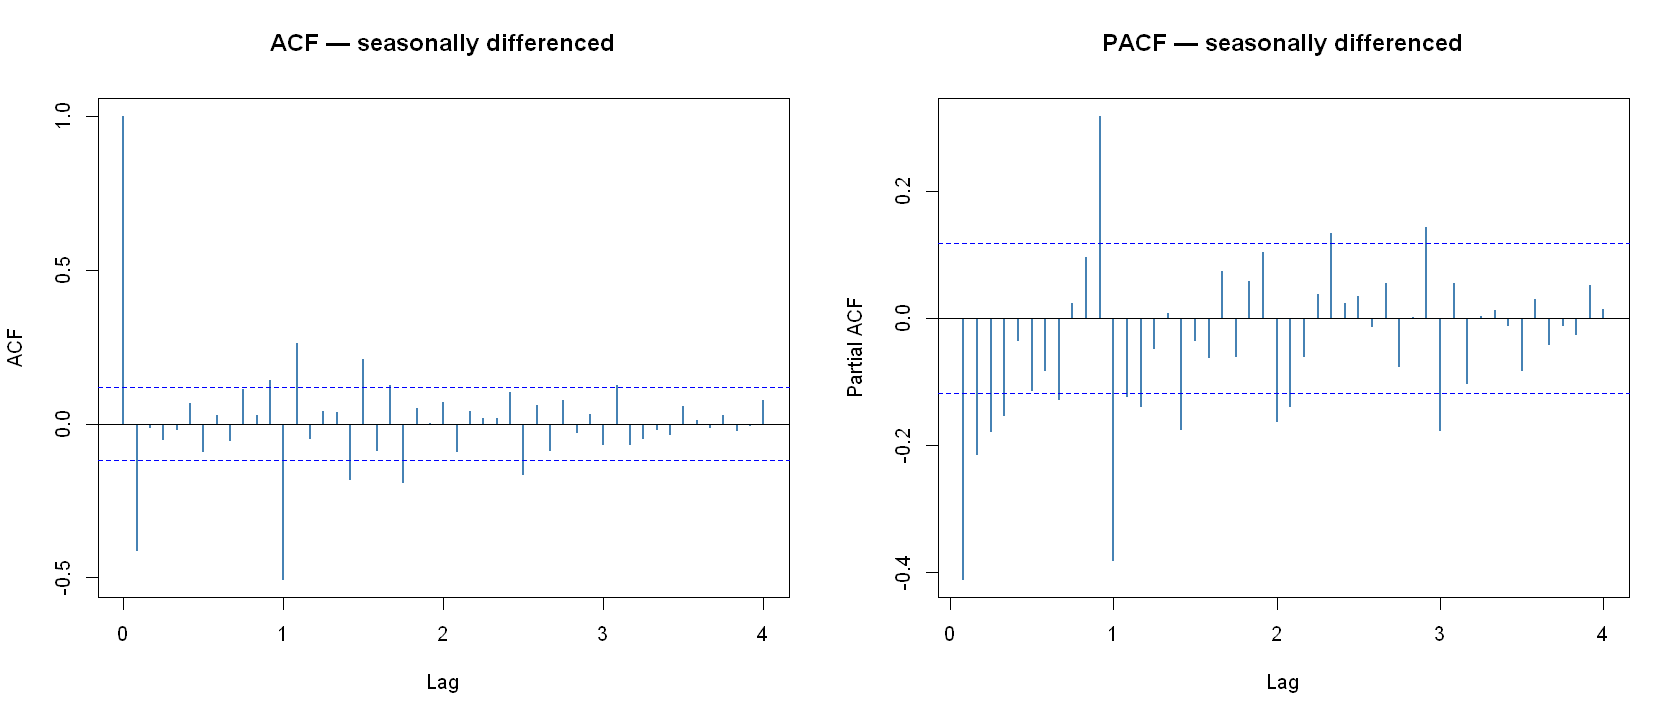

In [46]:
diff_log_s <- diff(diff_log, lag = 12)

set_theme()
par(mfrow = c(1, 2))
acf(diff_log_s,
    main    = "ACF — seasonally differenced",
    lag.max = 48,
    col     = "steelblue",
    lwd = 2)
pacf(diff_log_s,
     main    = "PACF — seasonally differenced",
     lag.max = 48,
     col     = "steelblue",
     lwd = 2)
par(mfrow = c(1, 1))


After seasonal differencing, the ACF shows a significant negative 
spike at lag 1 that cuts off immediately, suggesting q=1. A spike 
at the seasonal lag suggests Q=1. The PACF shows a large spike at 
lag 1 but the pattern is ambiguous between p=0 and p=1. We therefore 
propose three candidate models and let BIC decide:

- SARIMA(1,1,1)(0,1,1)[12]
- SARIMA(0,1,1)(0,1,1)[12]
- SARIMA(1,1,0)(0,1,1)[12]


## 3. Model Fitting and Diagnostics


### 3a. Fitting Candidate Models

We fit the three candidate SARIMA models and compare them using AIC and BIC. 
we prefer BIC for model selection 
as it penalizes complexity more heavily.

In [47]:
m1 <- arima(log_train,
            order    = c(1,1,1),
            seasonal = list(order = c(0,1,1), period = 12))

m2 <- arima(log_train,
            order    = c(0,1,1),
            seasonal = list(order = c(0,1,1), period = 12))

m3 <- arima(log_train,
            order    = c(1,1,0),
            seasonal = list(order = c(0,1,1), period = 12))

# Compare
model_names <- c("SARIMA(1,1,1)(0,1,1)[12]",
                 "SARIMA(0,1,1)(0,1,1)[12]",
                 "SARIMA(1,1,0)(0,1,1)[12]")

aic_vals <- c(AIC(m1), AIC(m2), AIC(m3))
bic_vals <- c(BIC(m1), BIC(m2), BIC(m3))

comparison <- data.frame(Model = model_names,
                         AIC   = round(aic_vals, 2),
                         BIC   = round(bic_vals, 2))
print(comparison)

                     Model     AIC     BIC
1 SARIMA(1,1,1)(0,1,1)[12] -391.90 -377.43
2 SARIMA(0,1,1)(0,1,1)[12] -388.99 -378.14
3 SARIMA(1,1,0)(0,1,1)[12] -372.06 -361.21


SARIMA(0,1,1)(0,1,1)[12] achieves the lowest BIC (-378.14) and is 
selected as the final model. Although SARIMA(1,1,1)(0,1,1)[12] has 
a slightly lower AIC, BIC is preferred as it penalizes complexity 
more heavily, favoring the more parsimonious model.


### 3b. Residual Diagnostics

We perform a thorough residual analysis on the final selected model which is SARIMA(0,1,1)(0,1,1)[12].


	Box-Ljung test

data:  res
X-squared = 31.151, df = 20, p-value = 0.05323



	Shapiro-Wilk normality test

data:  res
W = 0.99011, p-value = 0.04833


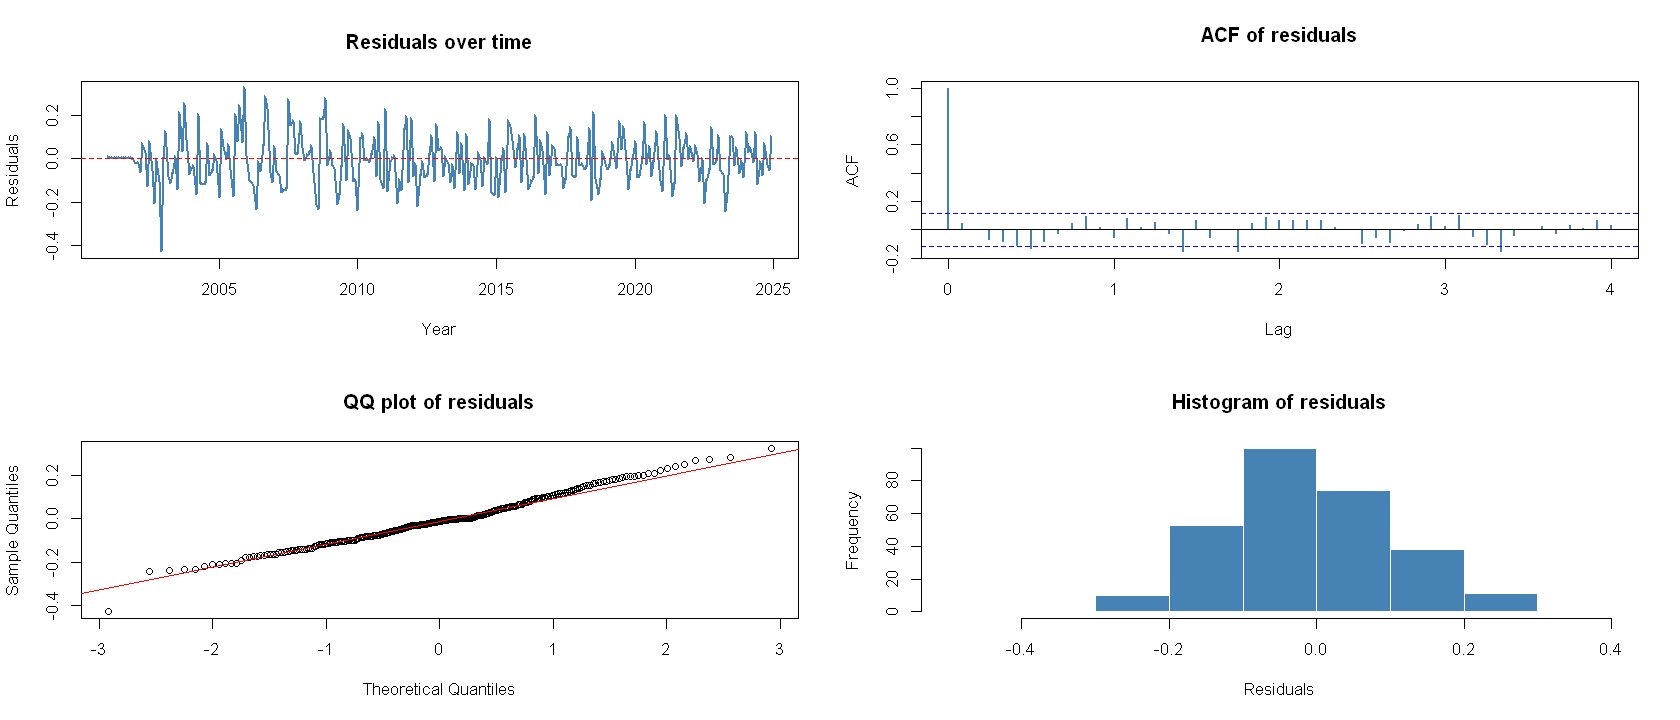

In [49]:
final_model <- m2

res <- residuals(final_model)

par(mfrow = c(2, 2))
set_theme()
plot(res,
     main = "Residuals over time",
     ylab = "Residuals",
     xlab = "Year",
     type = "o",
     col  = "steelblue",
     cex  = 0.3,
     lwd = 2)
abline(h = 0, col = "red", lty = 2)

acf(res,
    main    = "ACF of residuals",
    lag.max = 48,
    col     = "steelblue",
    lwd = 2)

qqnorm(res, main = "QQ plot of residuals")
qqline(res, col = "red")

hist(res,
     main   = "Histogram of residuals",
     xlab   = "Residuals",
     col    = "steelblue",
     border = "white")

par(mfrow = c(1, 1))

# Formal tests
Box.test(res, lag = 20, type = "Ljung-Box")
shapiro.test(res)

residuals behave approximately as white noise. The Box–Ljung test shows no significant autocorrelation (p = 0.053), while residuals are approximately normally distributed despite a slight deviation detected by the Shapiro–Wilk test (p = 0.048). Overall, the fitted model is adequate for forecasting.


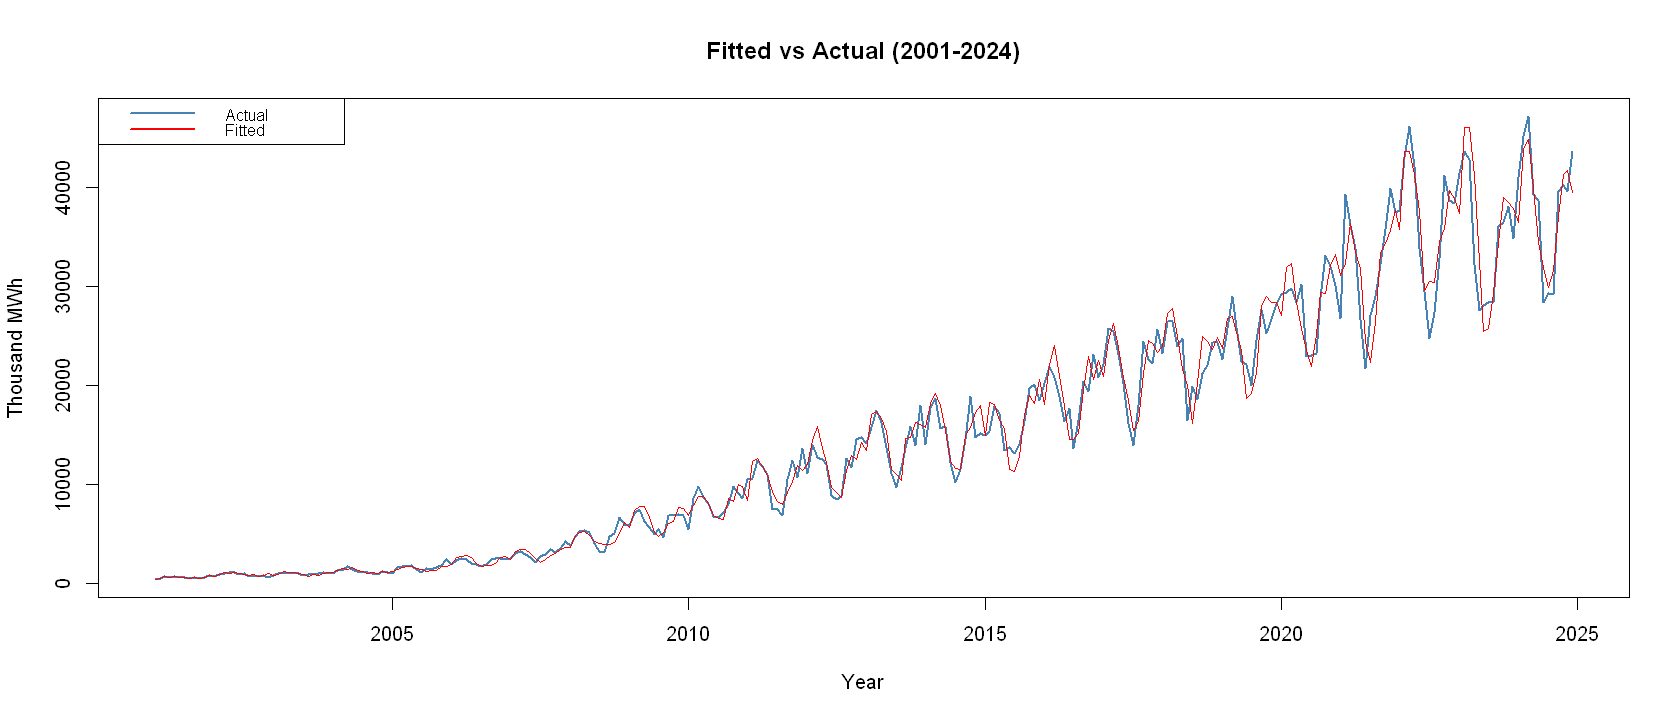

In [50]:
# Fitted values vs actual (in-sample fit)
fitted_vals <- exp(log_train - residuals(final_model))
set_theme()
plot(wind_train,
     main = "Fitted vs Actual (2001-2024)",
     ylab = "Thousand MWh",
     xlab = "Year",
     col  = "steelblue",
     lwd  = 2,
     type = "l")

lines(fitted_vals, col = "red", lwd = 1.5)

legend("topleft",
       legend = c("Actual", "Fitted"),
       col    = c("steelblue", "red"),
       lty    = 1,
       lwd    = 2,
       cex    = 0.8)


The fitted values track the actual wind generation closely throughout 
the entire training period (2001–2024), capturing both the strong 
upward trend and the seasonal fluctuations. This confirms that the 
SARIMA(0,1,1)(0,1,1)[12] model provides a good in-sample fit.



## 4. Forecasting

We withhold the year 2025 (12 observations) and forecast 12 steps ahead 
from the model fitted on 2001–2024. Forecasts are back-transformed from 
the log scale for interpretability.

RMSE: 4223.74 
MAE : 3630.21 
MAPE: 10.53 %
Mean of test set: 38768.69 
RMSE as % of mean: 10.9 %


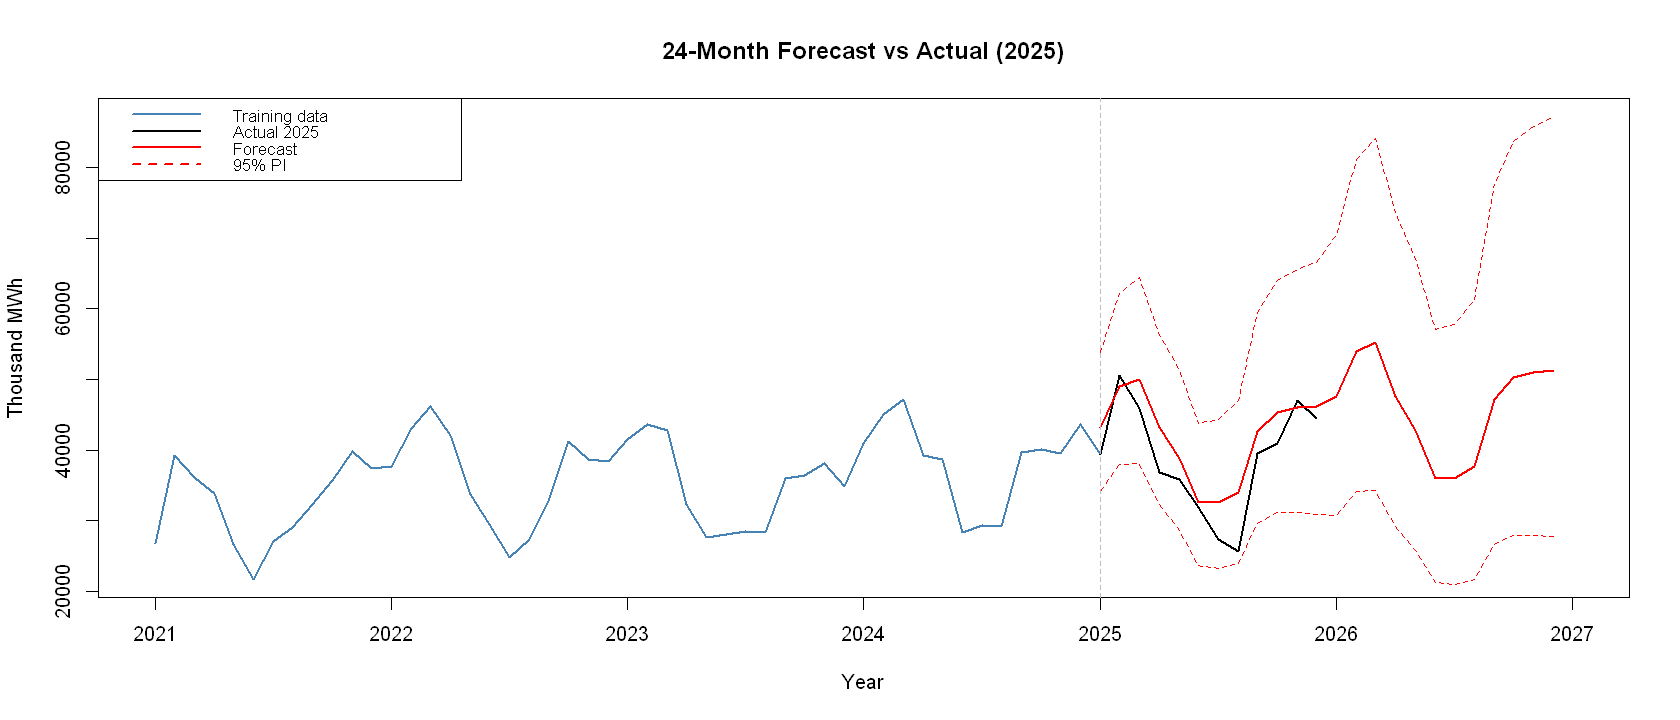

In [ ]:
fc <- predict(final_model, n.ahead = 24)

# Forecast variance
var_el <- fc$se^2

# Back-transform  to the original scale
fc_mean <- exp(fc$pred + 0.5 * var_el)
fc_lo95 <- exp(fc$pred - 1.96 * fc$se)
fc_hi95 <- exp(fc$pred + 1.96 * fc$se)

# Convert forecasts to ts objects
fc_ts <- ts(fc_mean, start = c(2025, 1), frequency = 12)
fc_lo <- ts(fc_lo95, start = c(2025, 1), frequency = 12)
fc_hi <- ts(fc_hi95, start = c(2025, 1), frequency = 12)


wind_all <- ts(
  c(as.numeric(wind_train), as.numeric(wind_test)),
  start = start(wind_train),
  frequency = frequency(wind_train)
)

# Show only recent years for more clarity
wind_recent <- window(wind_all, start = c(2021, 1))

set_theme()

plot(wind_recent,
     type = "l",
     col  = "steelblue",
     lwd  = 2,
     xlim = c(2021, 2027),
     ylim = range(c(wind_recent, fc_hi)),
     main = "24-Month Forecast vs Actual (2025)",
     xlab = "Year",
     ylab = "Thousand MWh")

# highlight test data (2025)
lines(wind_test, col = "black", lwd = 2)

# forecast mean
lines(fc_ts, col = "red", lwd = 2)

# prediction intervals
lines(fc_hi, col = "red", lty = 2)
lines(fc_lo, col = "red", lty = 2)

# vertical split line
abline(v = 2025, col = "gray", lty = 2)

legend("topleft",
       legend = c("Training data",
                  "Actual 2025",
                  "Forecast",
                  "95% PI"),
       col = c("steelblue", "black", "red", "red"),
       lty = c(1,1,1,2),
       lwd = 2,
       cex = 0.85)

# Forecast values of 2025
fc_2025 <- window(fc_ts, end = c(2025, 12))

RMSE <- sqrt(mean((fc_2025 - wind_test)^2))
MAE  <- mean(abs(fc_2025 - wind_test))
MAPE <- mean(abs((fc_2025 - wind_test) / wind_test)) * 100

cat("RMSE:", round(RMSE, 2), "\n")
cat("MAE :", round(MAE, 2), "\n")
cat("MAPE:", round(MAPE, 2), "%\n")

cat("Mean of test set:",
    round(mean(wind_test), 2), "\n")

cat("RMSE as % of mean:",
    round(100 * RMSE / mean(wind_test), 1), "%\n")

The model forecasts wind energy production for 2025–2026 and suggests that generation will continue following its historical seasonal pattern. 

For 2025, the observed values closely match the forecasts and remain within the 95% prediction intervals, indicating reliable short-term predictions. 

The RMSE represents 10.9% of the mean production level, and the MAPE of 10.53% indicates an average forecasting error of about 10%, which is acceptable given the natural variability of wind energy generation. 

The forecasts for 2026 indicate slightly higher production levels during peak periods compared to previous years, suggesting a potential increase in output, partly due to the establishment of additional wind facilities and improved production capacity, although uncertainty grows as reflected by the widening prediction intervals.



## 5. Seasonal Pattern Analysis


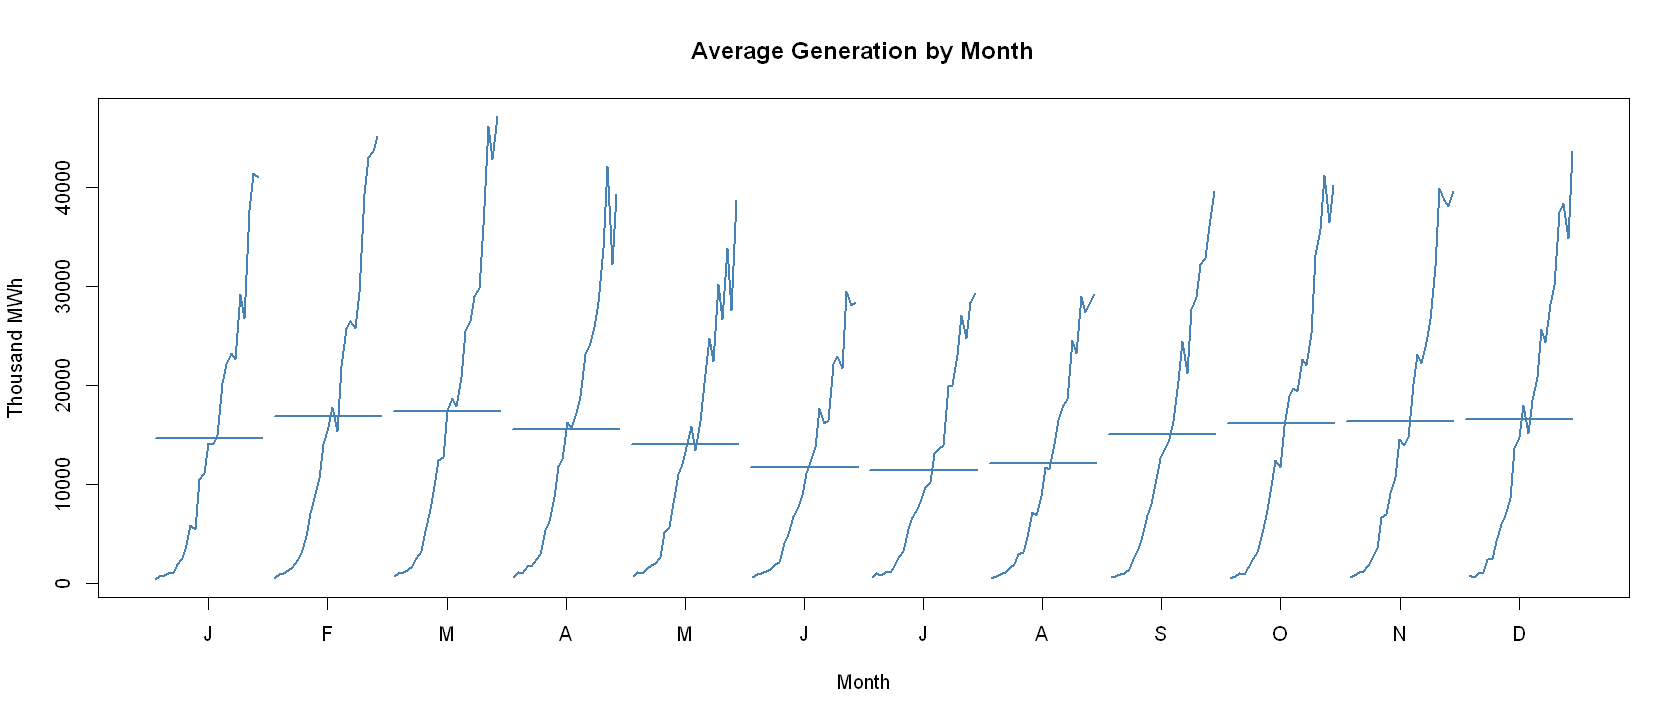

In [60]:
set_theme()
monthplot(wind_train,
          main = "Average Generation by Month",
          ylab = "Thousand MWh",
          xlab = "Month",
          col  = "steelblue",
          lwd  = 2)

The monthplot reveals a clear seasonal pattern in U.S. wind generation. 

Production is consistently highest in late winter and spring 
(February, March, April), driven by stronger wind patterns during 
these months. 

Generation drops significantly in summer (June, July, 
August), when winds are weaker. 

This seasonal cycle repeats every 
year and is precisely what the seasonal component of our 
SARIMA(0,1,1)(0,1,1)[12] model captures.


## 6. Discussion

This project analyzed monthly U.S. wind energy generation (2001–2024) 
following the three-phase methodology of identification, estimation, 
and forecasting. After log transformation and differencing, a 
SARIMA(0,1,1)(0,1,1)[12] model was selected based on BIC. Residual 
diagnostics confirmed that the residuals behave as white noise, 
validating the model.

The seasonal analysis revealed that wind generation peaks in February, 
March and April, and drops in summer months — a pattern successfully 
captured by the model's seasonal component. The 24-month forecast 
achieved a MAPE of 10.53%, indicating acceptable accuracy.

The main limitation is that wind generation growth is driven by policy 
and investment decisions that a linear time series model cannot fully 
capture. Future work could incorporate exogenous variables such as 
installed capacity using a SARIMAX framework.